# WSA_03 — XGBoost Peak-Risk Sensitivity

**Purpose.** Quantify Peak-Risk score and alert-policy sensitivity using the official frozen 0.06 threshold.

> Run from the project repository. Outputs are generated only from the project data and frozen model artifacts.

In [1]:
# Import libraries
from pathlib import Path
import sys, json, pandas as pd, numpy as np, matplotlib.pyplot as plt

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG = PROJECT_ROOT / "configs" / "weather_sensitivity.yaml"
CONFIG

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/weather_sensitivity.yaml')

In [3]:
# Import modules for weather_sensitivity
from src.ontario_peak_risk.weather_sensitivity.common import load_config, ensure_dirs

In [4]:
cfg, project_root = load_config(CONFIG)
paths = ensure_dirs(cfg, project_root)
print("Project root:", project_root)

Project root: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk


In [5]:
# Load the shared sensitivity master generated by WSA_02.
p = paths["outputs_dir"] / "WSA_sensitivity_master.parquet"
if not p.exists():
    raise FileNotFoundError(
        "WSA_sensitivity_master.parquet not found. Run WSA_02 successfully first."
    )

results = pd.read_parquet(p)

required = [
    "fsa",
    "forecast_origin",
    "target_timestamp",
    "horizon",
    "scenario",
    "temperature_delta_c",
    "baseline_temperature_c",
    "origin__Temp (°C)",
    "temperature_domain_status",
    "peak_risk_score",
    "baseline_peak_risk_score",
    "peak_risk_delta",
    "peak_alert",
    "baseline_peak_alert",
    "alert_changed",
    "alert_transition",
]
missing = [c for c in required if c not in results.columns]
if missing:
    raise KeyError(f"Missing expected WSA_03 columns: {missing}")

expected_rows = (
    len(cfg["analysis"]["fsas"])
    * int(cfg["analysis"]["horizons"])
    * len(cfg["analysis"]["scenarios_c"])
)
if len(results) != expected_rows:
    raise ValueError(
        f"Unexpected master row count: {len(results)}; expected {expected_rows}."
    )

xgb = results[required].copy()
xgb = xgb.sort_values(["fsa", "scenario", "horizon"]).reset_index(drop=True)

xgb.to_csv(paths["outputs_dir"] / "WSA_03_xgb_peak_risk_sensitivity.csv", index=False)

summary = (
    xgb.groupby("scenario", observed=True)
    .agg(
        mean_peak_risk_score=("peak_risk_score", "mean"),
        mean_peak_risk_delta=("peak_risk_delta", "mean"),
        min_peak_risk_delta=("peak_risk_delta", "min"),
        max_peak_risk_delta=("peak_risk_delta", "max"),
        alert_changes=("alert_changed", "sum"),
    )
    .reset_index()
)
summary.to_csv(
    paths["reports_dir"] / "WSA_03_peak_risk_scenario_summary.csv", index=False
)

display(summary)
print("Rows:", len(xgb))
print("Expected rows:", expected_rows)
print("WSA_03 data validation: PASS")


,scenario,mean_peak_risk_score,mean_peak_risk_delta,min_peak_risk_delta,max_peak_risk_delta,alert_changes
0,+2.5C,0.113147,-0.052340,-0.425148,0.003210,5
1,+5C,0.059753,-0.105733,-0.596323,-0.000004,17
2,-2.5C,0.202637,0.037150,-0.030891,0.273067,6
3,-5C,0.221364,0.055878,-0.018561,0.407749,8
4,Baseline,0.165486,0.000000,0.000000,0.000000,0


Rows: 720
Expected rows: 720
WSA_03 data validation: PASS


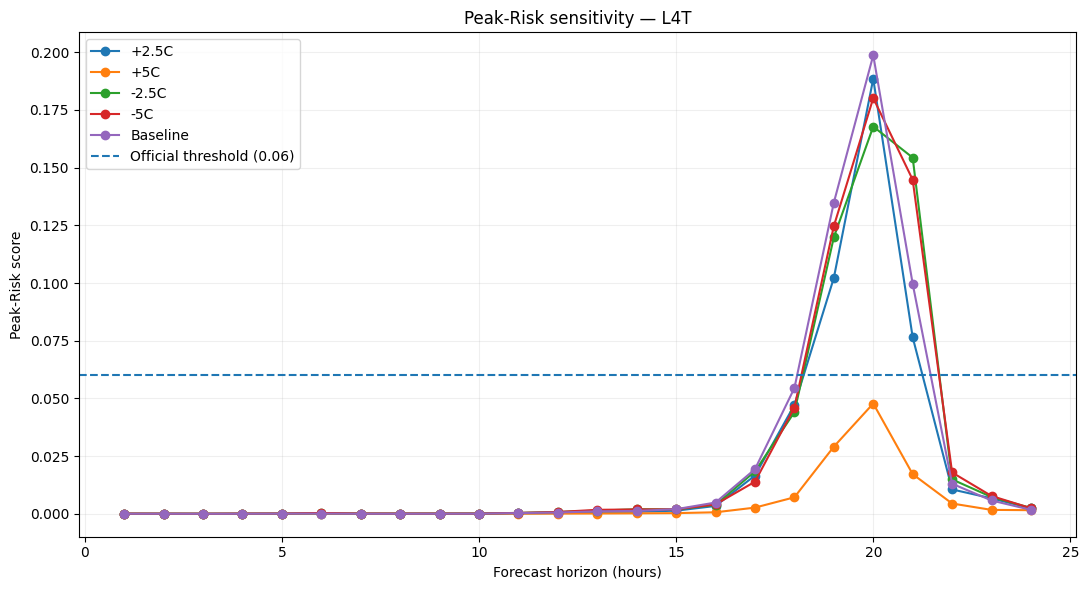

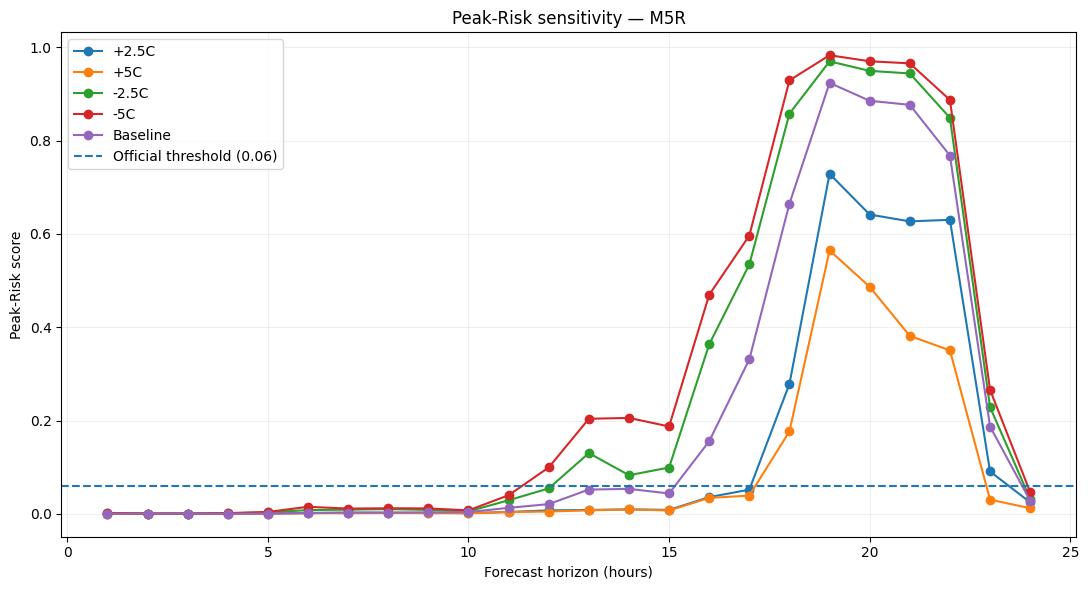

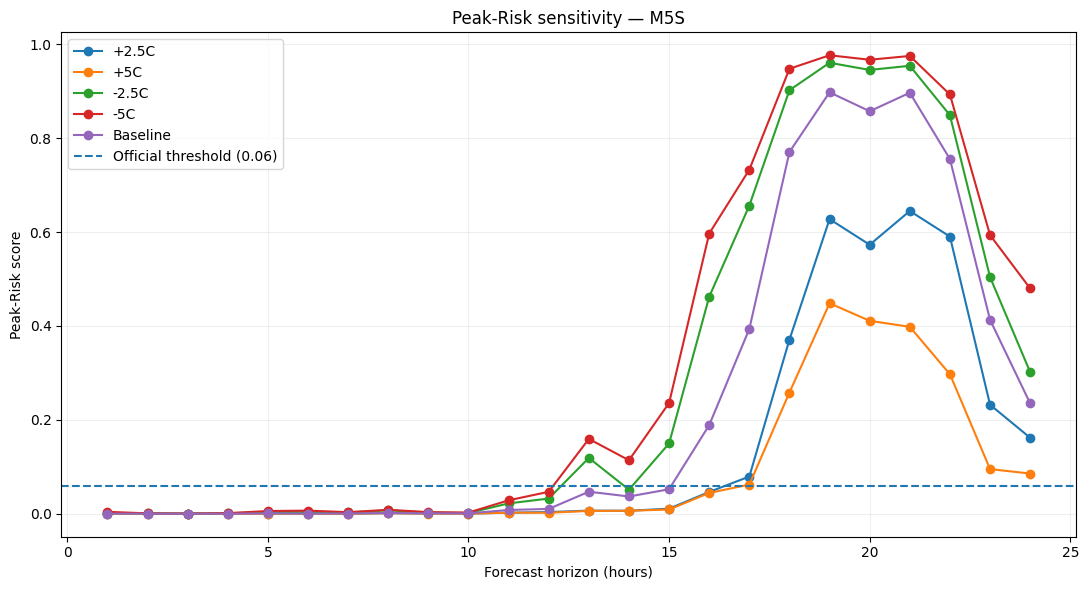

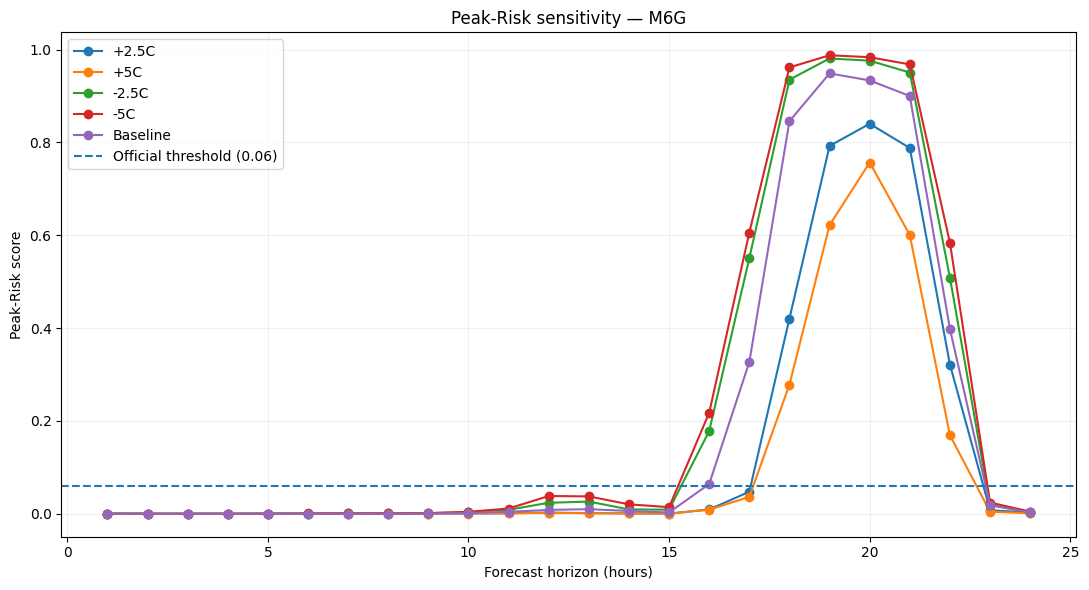

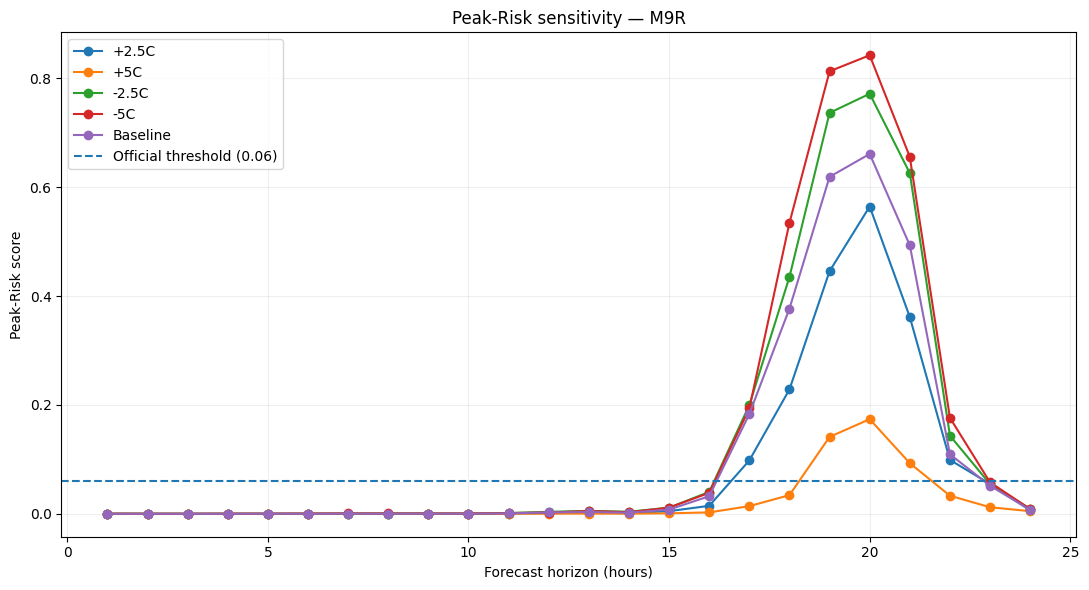

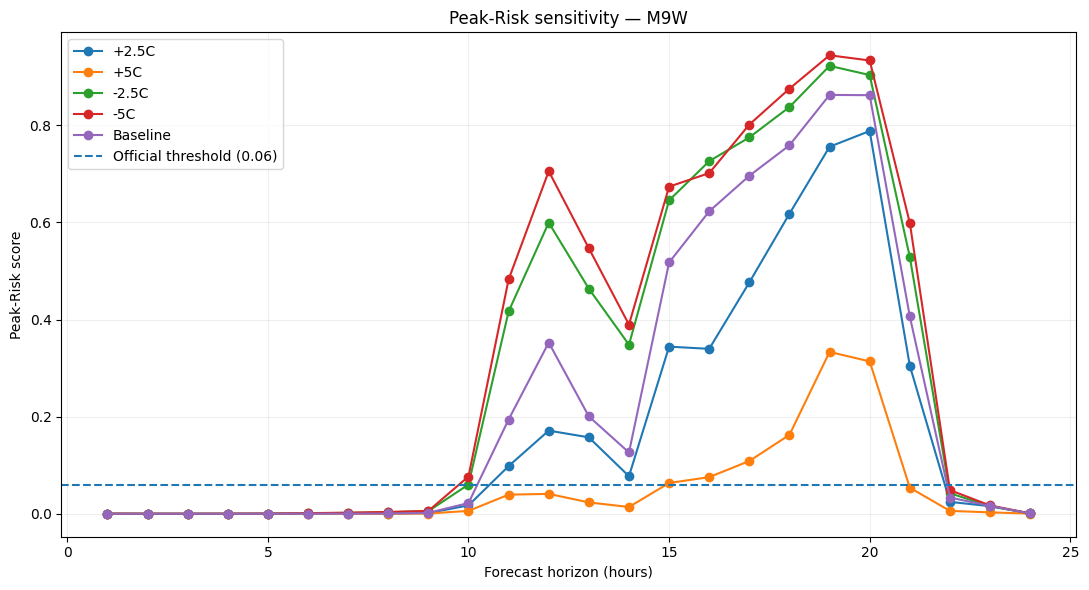

Alert changes: 36


,scenario,alert_transition,count
0,+2.5C,Alert -> No Alert,5
1,+5C,Alert -> No Alert,17
2,-2.5C,No Alert -> Alert,6
3,-5C,No Alert -> Alert,8


WSA_03 RESULT: COMPLETE


In [6]:
from src.ontario_peak_risk.weather_sensitivity.plotting import scenario_lines

threshold = float(cfg["analysis"]["official_peak_threshold"])

for fsa in cfg["analysis"]["fsas"]:
    fsa_xgb = xgb.loc[xgb["fsa"].eq(fsa)].sort_values(["scenario", "horizon"])
    if fsa_xgb.empty:
        raise ValueError(f"No Peak-Risk sensitivity rows found for FSA {fsa}.")

    fig = scenario_lines(
        fsa_xgb,
        "peak_risk_score",
        f"Peak-Risk sensitivity — {fsa}",
        "Peak-Risk score",
    )
    ax = fig.axes[0]
    ax.axhline(threshold, linestyle="--", label=f"Official threshold ({threshold:.2f})")
    ax.legend()
    fig.savefig(
        paths["figures_dir"] / f"WSA_03_XGB_{fsa}_risk_scenarios.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

# Persist only cases where the scenario changes the operational alert decision.
changes = xgb.loc[xgb["alert_changed"].astype(bool)].copy()
changes.to_csv(paths["reports_dir"] / "WSA_03_alert_transitions.csv", index=False)

print("Alert changes:", len(changes))
if not changes.empty:
    display(
        changes.groupby(["scenario", "alert_transition"], observed=True)
        .size()
        .rename("count")
        .reset_index()
    )
print("WSA_03 RESULT: COMPLETE")
